# 1. Installation Check

This notebook checks that Qiskit and the Aer simulator (IBM's local
quantum simulator) are installed correctly, then runs one very small
circuit end-to-end so you can see every kind of output you'll use in
the rest of this course:

- a circuit diagram (`draw("mpl")`)
- the exact quantum state as a probability bar chart (Statevector)
- a histogram of measurement results from the simulator

**Install first (in a terminal, not in this notebook):**
```
pip install qiskit qiskit-aer matplotlib pylatexenc jupyter
```

## Step 1: Import the libraries we need

In [1]:
import qiskit
import qiskit_aer
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_distribution, plot_histogram

print("Qiskit version:", qiskit.__version__)
print("Qiskit Aer version:", qiskit_aer.__version__)

Qiskit version: 2.5.2
Qiskit Aer version: 0.17.2


## Step 2: Build a very simple circuit

One qubit, one Hadamard gate. The Hadamard gate puts the qubit into
an equal superposition of `|0>` and `|1>`. We do NOT add measurement
yet, because we want to look at the pure quantum state first.

In [2]:
qc = QuantumCircuit(1)
qc.h(0)

print(qc.draw("text"))

   ┌───┐
q: ┤ H ├
   └───┘


## Step 3: Draw the circuit (visual diagram)

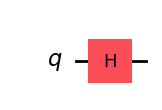

In [3]:
qc.draw("mpl")

## Step 4: Look at the exact quantum state (Statevector)

Before measuring, the qubit is in a superposition. Statevector lets
us see the exact probability of measuring `0` or `1`.

State probabilities: {np.str_('0'): np.float64(0.4999999999999999), np.str_('1'): np.float64(0.4999999999999999)}


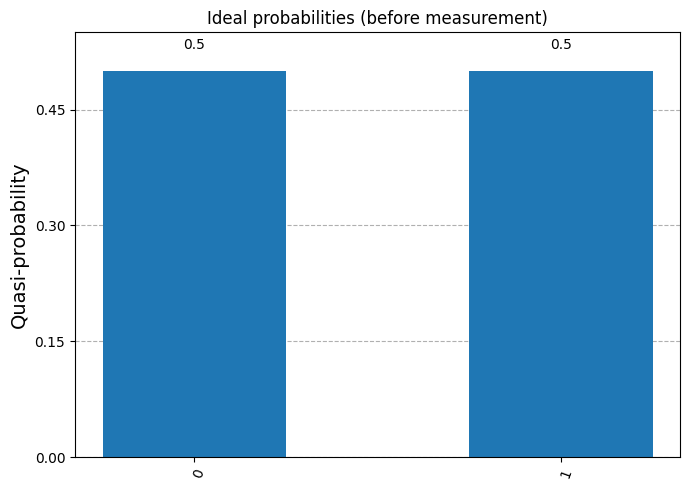

In [4]:
state = Statevector(qc)
probabilities = state.probabilities_dict()
print("State probabilities:", probabilities)

plot_distribution(probabilities, title="Ideal probabilities (before measurement)")

## Step 5: Add measurement and run on the Aer simulator

Now we add a measurement, and actually run the circuit many times
("shots") on IBM's Aer simulator to see real sampled results.

In [5]:
qc.measure_all()
print(qc.draw("text"))

        ┌───┐ ░ ┌─┐
     q: ┤ H ├─░─┤M├
        └───┘ ░ └╥┘
meas: 1/═════════╩═
                 0 


In [6]:
simulator = AerSimulator()
compiled_circuit = transpile(qc, simulator)
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts()

print("Measurement counts (1024 shots):", counts)

Measurement counts (1024 shots): {'0': 529, '1': 495}


## Step 6: Plot the measurement histogram

You should see roughly 50% `0` and 50% `1`, matching the ideal
probabilities from Step 4.

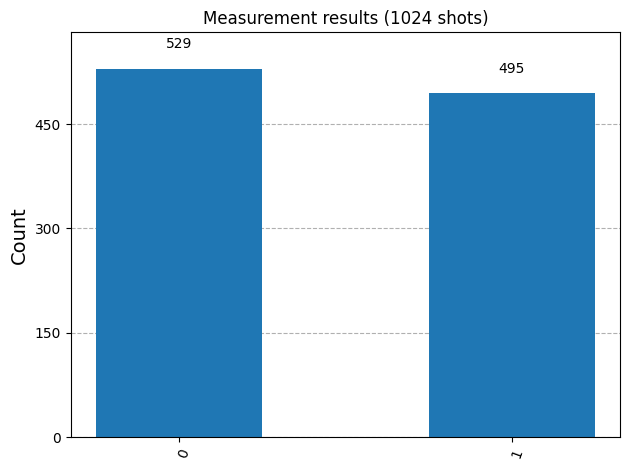

In [7]:
plot_histogram(counts, title="Measurement results (1024 shots)")

If you saw a circuit diagram, a probability bar chart, and a
histogram close to 50/50 above, **Qiskit and Aer are installed and
working correctly.**